In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import yaml

from pmt_analysis import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Read Data

In [2]:
data_dir = Path("data/calibLED/260611/segmented_wTrig")
files = sorted(data_dir.glob("southCovered_525MHz_fewHours_trig1800uV-1.h5")) 
# files = sorted(data_dir.glob("southCovered_525MHz_fewHours_trig1800uV-*.h5")) 

for file in files:
    print(file)
print(f"Number of files: {len(files)}")

data/calibLED/260611/segmented_wTrig/southCovered_525MHz_fewHours_trig1800uV-1.h5
Number of files: 1


In [3]:
maxEvts = 1000 # small sample size
time_s, voltage_sample_V, metadata = read_keysight_h5_direct(
    files[0],
    segment_numbers=range(maxEvts),
)
time_ns, voltage_sample_mV, adc_step_mV, units_time, units_voltage = standard_units(
    time_s,
    voltage_sample_V,
    metadata,
)

print(f"Sample waveforms: {voltage_sample_mV.shape}")
print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV")

Sample waveforms: (999, 1000)
Time range: -27.275 to 35.163 ns
Sampling step: 0.06250 ns
ADC step: 0.001276 mV


# Set Config. Values

In [4]:
# default config
with open('config_default.yml', 'r') as file:
    # Load and parse the YAML content safely
    config = yaml.safe_load(file)['DC_525MHz_fewHours_trig1800uV']['general']

## config
baseline_window_ns = (time_ns[0], time_ns[0]+config['baseline_window_width_ns'])
integration_window_ns  = (config['integration_window_ns'][0], config['integration_window_ns'][1])
peak_search_window_ns  = (config['peak_search_window_ns'][0], config['peak_search_window_ns'][1])
allowed_peak_window_ns = (config['allowed_peak_window_ns'][0], config['allowed_peak_window_ns'][1])
global_peak_voltage_max_mV = None if (config['global_peak_voltage_max_mV']=='None') else (config['global_peak_voltage_max_mV'])
out_of_window_peak_voltage_max_mV = config['out_of_window_peak_voltage_max_mV']

config



{'baseline_window_width_ns': 20,
 'integration_window_ns': [-1, 9],
 'peak_search_window_ns': [-1, 9],
 'global_peak_voltage_max_mV': 'None',
 'out_of_window_peak_voltage_max_mV': -1.8,
 'allowed_peak_window_ns': [-1, 9]}

In [5]:
### not in config
threshold_mV = 0. # threshold to compute mean waveform (if no cut, the baseline dominates)
rise_low_fraction = 0.1
rise_high_fraction = 0.9
show_residual_errorbars = True

# Selection

- remove peaks that are clearely out of time (+ small threshold to define "a peak")

In [6]:
selection = collect_peak_time_voltage_selection(
    files,
    baseline_window_ns=baseline_window_ns,
    peak_window_ns=allowed_peak_window_ns,
    global_peak_voltage_max_mV=global_peak_voltage_max_mV, # cut all events with peak higher below a cut (i.e. remove small waveforms)
    out_of_window_peak_voltage_max_mV=out_of_window_peak_voltage_max_mV,
    peak_search_window_ns=peak_search_window_ns,
    selection_mask=None,
    chunk_size=4096,
    low_fraction=rise_low_fraction,
    high_fraction=rise_high_fraction,
)

print(f'selection efficiency = {selection['efficiency']*100} %  ({selection['n_kept']} / {selection['n_total']})')
print(f'events whose peak passes the “real pulse” voltage threshold (full time window) = {np.sum( selection['real_peak_mask'] )}')
print(f'events whose measured peak time is inside peak_window_ns    = {np.sum( selection['in_peak_window_mask'] )}')
mask = (selection['real_peak_mask']==True) & (selection['in_peak_window_mask']==True)
real_peaks_sel = selection['peak_value_mV'][mask]
print(f'number of events with a "real peak" inside the selected peak widnow = {real_peaks_sel.shape[0]}  ({real_peaks_sel.shape[0]*100 / selection['n_total']:.2f} %)')

# for k in selection.keys():
#     print(k)

selection efficiency = 100.0 %  (31682 / 31682)
events whose peak passes the “real pulse” voltage threshold (full time window) = 7322
events whose measured peak time is inside peak_window_ns    = 31682
number of events with a "real peak" inside the selected peak widnow = 7322  (23.11 %)


In [7]:
summary = summarize_waveforms(
    files,
    baseline_window_ns=baseline_window_ns,
    chunk_size=4096,
    selection_mask=selection["keep_mask"]
)

print(f"Baseline residual is centered near zero?: {np.mean(summary['baseline_check_mV']):.3e} mV")

# for k in summary.keys():
#     print(k)

Baseline residual is centered near zero?: 1.131e-09 mV


# Charge

In [8]:
selected_charges_by_window = compute_charges_for_windows(
    files,
    baseline_window_ns=baseline_window_ns,
    integration_windows_ns=[integration_window_ns],
    selection_mask=selection["keep_mask"],
    chunk_size=4096,
)
charge_mV_ns = selected_charges_by_window[integration_window_ns]

print(f"Selected events: {selection['n_kept']} / {selection['n_total']} ({selection['efficiency']:.3%})")

Selected events: 31682 / 31682 (100.000%)


# Fits

In [9]:
with open('config_default.yml', 'r') as file:
    # Load and parse the YAML content safely
    fit_general = yaml.safe_load(file)['DC_525MHz_fewHours_trig1800uV']['fit_general']

fit_range = (fit_general['fit_range'][0], fit_general['fit_range'][1])
nbins = fit_general['fit_nbins']

fit_general

{'fit_range': [-6.0, 150.0], 'fit_nbins': 250}

## Simple Poisson model

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,31682.00,15841.0000,63364.0,False,28422.407552,168.683575
1,mu_pe,0.03,0.0010,5.0,False,0.013783,0.000807
2,q0_mV_ns,0.80,-6.0000,10.0,False,1.023291,0.004981
3,sigma0_mV_ns,0.90,0.0001,50.0,False,0.817953,0.003403
4,q1_mV_ns,12.00,12.0000,12.0,True,12.000000,0.000000
5,sigma1_mV_ns,10.00,10.0000,10.0,True,10.000000,0.000000


chi2/ndof: 13.291


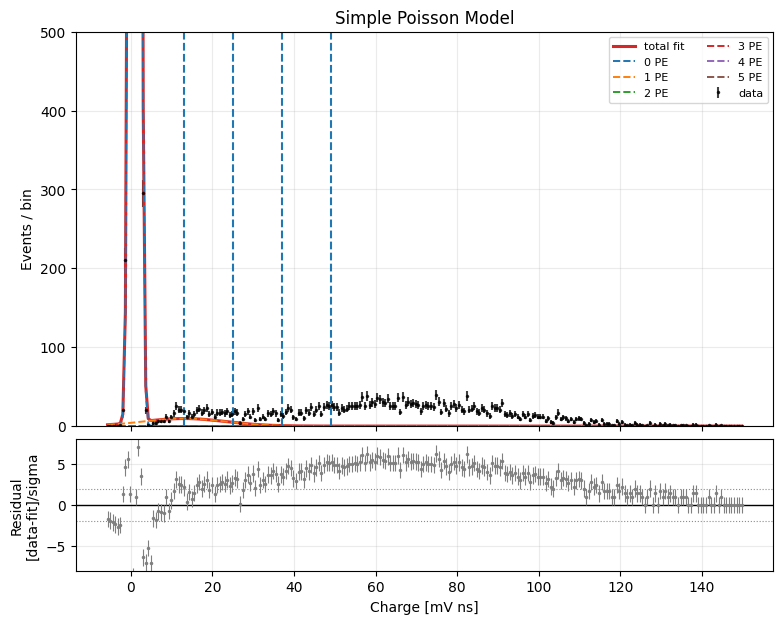

In [10]:
maxPE = 5

poisson_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total": [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.8, -6.0, 10.0, False],
    "sigma0_mV_ns": [0.9, 1e-4, 50.0, False],
    "q1_mV_ns":     [12.0, 5.0, 20.0, True],
    "sigma1_mV_ns": [10.0, 0.2, 40.0, True],
    "mu_pe":        [0.03, 0.001, 5.0, False],
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_pe=maxPE,
    p0=poisson_fit_p0,
)

fit_all = fit_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
# print_fit_result_table(fit_all)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="Simple Poisson Model",
    logscale=False,
    ylims= (0, 500),
)

# ax.axvline( 5, ls="--")

q0_mV_ns = table.set_index("parameter").loc["q0_mV_ns", "fit_value"]
q1_mV_ns = table.set_index("parameter").loc["q1_mV_ns", "fit_value"]
for i in range(1, maxPE):
    ax.axvline(q0_mV_ns + i*q1_mV_ns, ls="--")




## Poisson with asymmetric widths

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_pedestal,30000.00,0.00,63364.0,False,2.809106e+04,167.681253
1,q0_mV_ns,0.80,-10.00,20.0,False,1.022558e+00,0.004971
2,sigma0_mV_ns,0.80,0.05,30.0,False,8.222918e-01,0.003376
3,q1_mV_ns,15.00,5.00,20.0,False,2.000000e+01,0.444559
4,sigma1_left_mV_ns,8.00,3.00,40.0,False,7.629258e+00,0.582960
5,sigma1_right_mV_ns,8.00,3.00,40.0,False,1.490164e+01,0.538518
6,n_1pe,7920.50,0.00,63364.0,False,6.834814e+02,49.170006
7,n_2pe,1584.10,0.00,63364.0,False,1.424323e-17,121.123251
8,n_3pe,316.82,0.00,63364.0,False,2.296184e+03,124.092715
9,constant_per_bin,0.10,0.00,inf,False,6.957342e-02,0.190040


chi2/ndof: 2.445


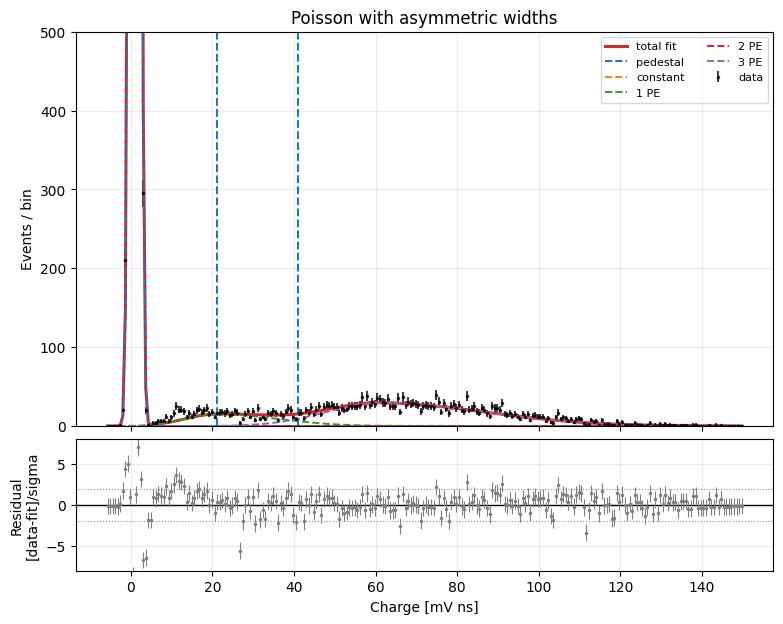

In [11]:
maxPE = 3

free_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed].
    # "n_pedestal": [0.5 * len(fit_charge), 0.0, 2.0 * len(fit_charge), False],
    "n_pedestal": [30000, 0.0, 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns": [0.8, -10.0, 20.0, False],
    "sigma0_mV_ns": [0.8, 0.05, 30.0, False],
    "q1_mV_ns": [15.0, 5.0, 20.0, False],
    "sigma1_left_mV_ns": [8.0, 3., 40.0, False],
    "sigma1_right_mV_ns": [8.0, 3., 40, False],
    "n_1pe": [0.25 * len(charge_mV_ns), 0.0, 2.0 * len(charge_mV_ns), False],
    "n_2pe": [0.05 * len(charge_mV_ns), 0.0, 2.0 * len(charge_mV_ns), False],
    "n_3pe": [0.01 * len(charge_mV_ns), 0.0, 2.0 * len(charge_mV_ns), False],
    "constant_per_bin": [0.1, 0.0, np.inf, False],
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_pe=maxPE,
    p0=free_fit_p0,
)

fit_all = fit_free_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="Poisson with asymmetric widths",
    logscale=False,
    ylims= (0, 500),
)

q0_mV_ns = table.set_index("parameter").loc["q0_mV_ns", "fit_value"]
q1_mV_ns = table.set_index("parameter").loc["q1_mV_ns", "fit_value"]
for i in range(1, maxPE):
    ax.axvline(q0_mV_ns + i*q1_mV_ns, ls="--")


## Bellamy

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,31682.00,15841.0000,63364.0,False,29902.256378,1.133245e+10
1,mu_pe,0.03,0.0010,5.0,False,0.026967,1.163381e-03
2,q0_mV_ns,0.80,-6.0000,10.0,False,1.022835,5.081504e-03
3,sigma0_mV_ns,0.90,0.0001,50.0,False,0.818710,3.563348e-03
4,q1_mV_ns,12.00,5.0000,20.0,False,19.991404,6.477587e-01
5,sigma1_mV_ns,10.00,0.2000,40.0,False,12.547624,6.083535e-01
6,w,0.03,0.0000,1.0,False,0.049709,3.601442e+05
7,alpha,-1.00,-10.0000,10.0,False,-1.000000,0.000000e+00


chi2/ndof: 11.970


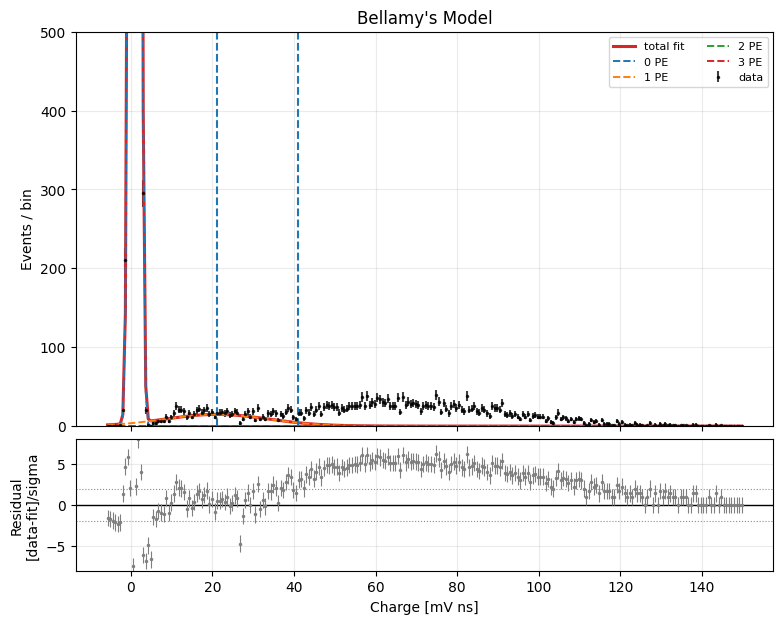

In [12]:
maxPE = 3

bellamy_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.8, -6.0, 10.0, False],
    "sigma0_mV_ns": [0.9, 1e-4, 50.0, False],
    "q1_mV_ns":     [12.0, 5.0, 20.0, False],
    "sigma1_mV_ns": [10.0, 0.2, 40.0, False],
    "mu_pe":        [0.03, 0.001, 5.0, False],
    "w":     [0.03, 0., 1., False],
    "alpha": [-1., -10., 10., False],
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_pe=maxPE,
    p0=bellamy_fit_p0,
)

fit_all = fit_bellamy_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="Bellamy's Model",
    logscale=False,
    ylims= (0, 500),
)

q0_mV_ns = table.set_index("parameter").loc["q0_mV_ns", "fit_value"]
q1_mV_ns = table.set_index("parameter").loc["q1_mV_ns", "fit_value"]
for i in range(1, maxPE):
    ax.axvline(q0_mV_ns + i*q1_mV_ns, ls="--")


## Two-paths

Check formula

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,31682.00,15841.0000,63364.0,False,31169.968753,176.743562
1,mu_pe,0.03,0.0010,5.0,False,0.103521,0.001909
2,q0_mV_ns,0.80,-6.0000,10.0,False,1.022656,0.004969
3,sigma0_mV_ns,0.90,0.0001,50.0,False,0.821893,0.003370
4,g1_mV_ns,12.00,5.0000,20.0,False,16.133470,0.446774
5,sigma_g1_mV_ns,10.00,0.2000,40.0,False,5.678388,0.404976
6,g2_mV_ns,20.00,0.0000,150.0,False,64.028096,0.618884
7,sigma_g2_mV_ns,10.00,0.0000,150.0,False,22.280956,0.538103
8,alpha,0.50,0.0000,1.0,False,0.868603,0.009970


chi2/ndof: 2.292


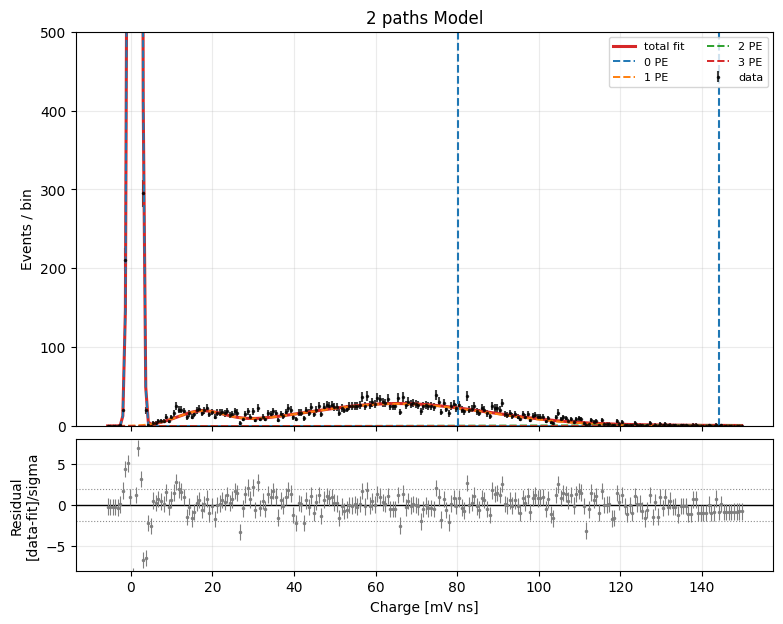

In [25]:
maxPE = 3

TwoPaths_fit_p0 = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":        [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "mu_pe":          [0.03, 0.001, 5.0, False],
    "q0_mV_ns":       [0.8, -6.0, 10.0, False],
    "sigma0_mV_ns":   [0.9, 1e-4, 50.0, False],
    "g1_mV_ns":       [12.0, 5.0, 20.0, False],
    "sigma_g1_mV_ns":   [10.0, 0.2, 40.0, False],
    "g2_mV_ns":       [20., 0., 150., False],
    "sigma_g2_mV_ns": [10, 0., 150, False],
    "alpha":          [0.5, 0., 1., False],
}

fit_kwargs = dict(
    fit_range=fit_range,
    bins=nbins,
    max_pe=maxPE,
    p0=TwoPaths_fit_p0,
)

fit_all = fit_dynode_spe_spectrum(charge_mV_ns, **fit_kwargs)

table = fit_result_table(fit_all)
display(table)
print(f"chi2/ndof: {fit_all['chi2'] / fit_all['ndof']:.3f}")

fig, ax, ax_resid = plot_fit_result(
    fit_all,
    title="2 paths Model",
    logscale=False,
    ylims= (0, 500),
)

q0_mV_ns = table.set_index("parameter").loc["g1_mV_ns", "fit_value"]
q1_mV_ns = table.set_index("parameter").loc["g2_mV_ns", "fit_value"]
for i in range(1, maxPE):
    ax.axvline(q0_mV_ns + i*q1_mV_ns, ls="--")
